# CNN Performance Analysis

Analyze the performance of the CNN model on CIFAR10 dataset.


In [2]:
import matplotlib.pyplot as plt
import time
import importlib
import cnn_train
from cnn_model import CNN

# ensure latest training loop is used (e.g., logging tweaks)
cnn_train = importlib.reload(cnn_train)
train = cnn_train.train

# Display model architecture
print("CNN Model Architecture:")
print("=" * 50)
model = CNN(n_channels=3, n_classes=10)
print(model)
print("=" * 50)


CNN Model Architecture:
CNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (conv7): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv8): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

## Training

Use the `train()` function from `cnn_train.py` with default parameters


In [3]:
# Using default parameters from cnn_train.py:
# - learning_rate: 1e-4
# - batch_size: 32
# - max_steps: 5000
# - eval_freq: 500
# - data_dir: '../Part 1/data' (use existing dataset)

In [ ]:
start_time = time.time()

# Call train() with default parameters, but use existing dataset
model, history = train(data_dir='../Part 1/data', return_history=True)

elapsed_time = time.time() - start_time
print(f'\nTraining completed in {elapsed_time/60:.2f} minutes')

train_losses = history['train_loss']
train_accs = history['train_acc']
test_accs = history['test_acc']
steps = history['steps']
# It's too long to train 5000 epochs(over 12 hours), and it leads to overfitting.
# Therefore, I choose to use early stop and evaluate more frequently.
# You can see the new result in the following cell.


![train trial](./train_trial.png)

In [4]:
start_time = time.time()

model, history = train(
    data_dir='../Part 1/data',
    max_steps=500,
    eval_freq=5,
    return_history=True,
    early_stopping=True,
    patience=5,
    min_delta=0.001
)

elapsed_time = time.time() - start_time
print(f'\nTraining completed in {elapsed_time/60:.2f} minutes (wall clock)')

train_losses = history['train_loss']
train_accs = history['train_acc']
test_accs = history['test_acc']
steps = history['steps']


Using device: cuda
CIFAR10 dataset found, skipping download...


Epoch [1/500] training loss: 1.7137
Epoch [5/500]
Loss: 0.6743, Train Acc: 76.60%, Test Acc: 75.11%
Epoch [10/500]
Loss: 0.4445, Train Acc: 84.52%, Test Acc: 81.44%
Epoch [15/500]
Loss: 0.3059, Train Acc: 89.39%, Test Acc: 82.99%
Epoch [20/500] training loss: 0.2533
Epoch [20/500]
Loss: 0.2533, Train Acc: 91.13%, Test Acc: 83.07%
Epoch [25/500]
Loss: 0.1497, Train Acc: 94.76%, Test Acc: 85.00%
Epoch [30/500]
Loss: 0.1419, Train Acc: 95.05%, Test Acc: 84.98%
No improvement in validation for 1 eval(s)
Epoch [35/500]
Loss: 0.1073, Train Acc: 96.32%, Test Acc: 84.79%
No improvement in validation for 2 eval(s)
Epoch [40/500] training loss: 0.1017
Epoch [40/500]
Loss: 0.0860, Train Acc: 96.97%, Test Acc: 85.32%
Epoch [45/500]
Loss: 0.0667, Train Acc: 97.79%, Test Acc: 85.68%
Epoch [50/500]
Loss: 0.0972, Train Acc: 96.69%, Test Acc: 84.82%
No improvement in validation for 1 eval(s)
Epoch [55/500]
Loss: 0.0611, Train Acc: 97.96%, Test Acc: 85.80%
Epoch [60/500] training loss: 0.0632
Epoch [60/

## Performance Visualization


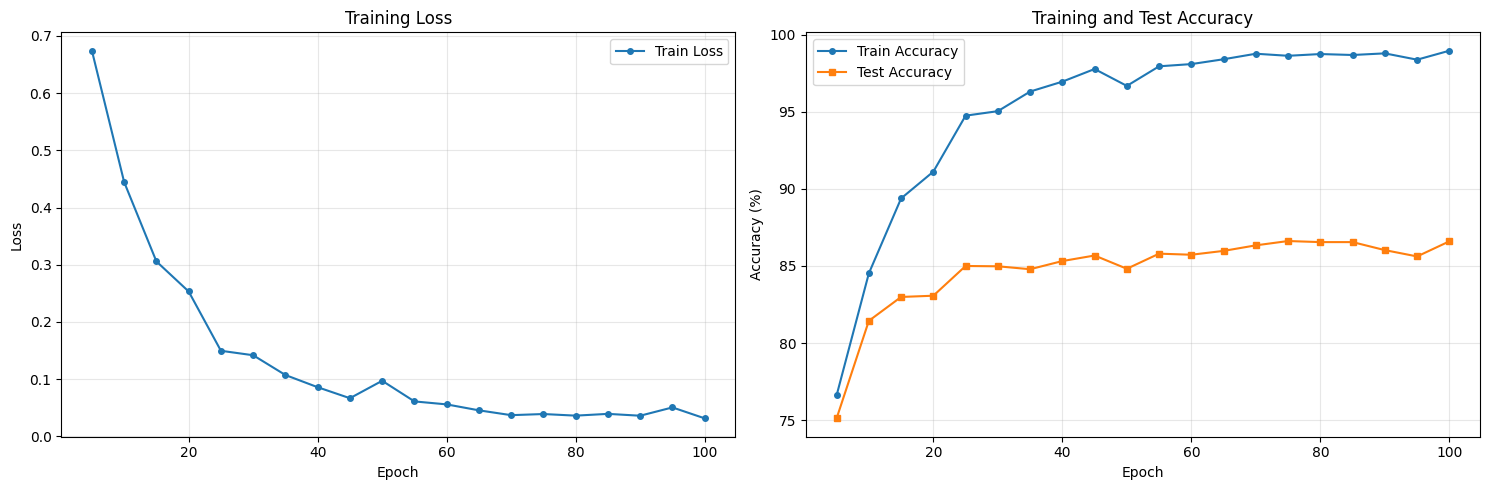

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(steps, train_losses, 'o-', label='Train Loss', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, train_accs, 'o-', label='Train Accuracy', markersize=4)
axes[1].plot(steps, test_accs, 's-', label='Test Accuracy', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Final Results


In [6]:
print(f"Final Training Accuracy: {train_accs[-1]:.2f}%")
print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")
print(f"Final Training Loss: {train_losses[-1]:.4f}")


Final Training Accuracy: 98.97%
Final Test Accuracy: 86.60%
Final Training Loss: 0.0315
